# Feature clustering & separability

Visualize handcrafted features and learned representations by behaviour label.

**Paper figures:**
- t-SNE on handcrafted features → `img/tsne_features.pdf` (cell under "t-SNE" section)
- t-SNE on learned representations (single model) → `img/tsne_learned_representations.pdf` (cell under "Single-model" section)

In [1]:
import os

os.chdir("../")

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib.lines import Line2D
from matplotlib import colormaps
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.classification.datamodule import BehaviourDataModule
from src.classification.model_selection import LOCO
from src.classification.models import MODEL_REGISTRY
from src.classification.trainer import BehaviourClassifier
from script.train import parse_input

## Load data

In [3]:
DATASET_DIR = "data/dataset"

# Load features and labels
features_df = pd.read_parquet(f"{DATASET_DIR}/features_windowed.parquet")
labels_df = pd.read_parquet(f"{DATASET_DIR}/labels.parquet")

# Merge on key columns
df = features_df.merge(labels_df, on=["video_id", "bird_id", "window"])

# Feature columns (drop keys and metadata)
skip_cols = {"video_id", "bird_id", "window", "n_frames",
             "bird_description", "time", "time_str",
             "behav", "behav_group", "behav_label"}
feat_cols = [c for c in df.columns if c not in skip_cols]

print(f"Samples: {len(df)}, Features: {len(feat_cols)}")
print(f"Labels: {df['behav_label'].value_counts().to_dict()}")
print(f"Feature cols: {feat_cols}")

Samples: 14716, Features: 171
Labels: {'none': 12585, 'worm': 1345, 'locomotor': 585, 'social': 201}
Feature cols: ['mask_area_mean', 'mask_area_std', 'mask_area_median', 'mask_area_mad', 'mask_area_skew', 'mask_area_kurt', 'mask_area_cv', 'mask_area_q10', 'mask_area_q90', 'aspect_ratio_mean', 'aspect_ratio_std', 'aspect_ratio_median', 'aspect_ratio_mad', 'aspect_ratio_skew', 'aspect_ratio_kurt', 'aspect_ratio_cv', 'aspect_ratio_q10', 'aspect_ratio_q90', 'velocity_mean', 'velocity_std', 'velocity_median', 'velocity_mad', 'velocity_skew', 'velocity_kurt', 'velocity_cv', 'velocity_q10', 'velocity_q90', 'acceleration_mean', 'acceleration_std', 'acceleration_median', 'acceleration_mad', 'acceleration_skew', 'acceleration_kurt', 'acceleration_cv', 'acceleration_q10', 'acceleration_q90', 'area_change_rate_mean', 'area_change_rate_std', 'area_change_rate_median', 'area_change_rate_mad', 'area_change_rate_skew', 'area_change_rate_kurt', 'area_change_rate_cv', 'area_change_rate_q10', 'area_chan

In [4]:
# Standardize features
X = df[feat_cols].fillna(df[feat_cols].median()).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.clip(X_scaled, -5, 5)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0)[:3].round(6)}")
print(f"Std  (should be ~1): {X_scaled.std(axis=0)[:3].round(6)}")

X_scaled shape: (14716, 171)
Mean (should be ~0): [-0.00033  -0.01167  -0.000468]
Std  (should be ~1): [0.998079 0.924586 0.997199]


In [5]:
# Fine-grained behaviour labels + color palettes (needed for scatter plots below)
MIN_COUNT = 5  # behaviours below this are grouped as "Other"


def primary_behav(behav, group):
    """Extract primary fine-grained behaviour for a given group."""
    if behav == "none":
        return "None"
    parts = [p.strip() for p in behav.split(",")]
    if group == "worm":
        worm_parts = [p for p in parts if p.startswith("Worm")]
        return worm_parts[0] if worm_parts else parts[0]
    elif group == "social":
        social_parts = [p for p in parts if "Sparring" in p]
        return social_parts[0] if social_parts else parts[0]
    else:
        return parts[0]


df["behav_primary"] = df.apply(
    lambda r: primary_behav(r["behav"], r["behav_label"]), axis=1
)

# Collapse rare behaviours into "Other <group>"
for group in ["worm", "locomotor", "social"]:
    gmask = df["behav_label"] == group
    counts = df.loc[gmask, "behav_primary"].value_counts()
    rare = counts[counts < MIN_COUNT].index
    df.loc[gmask & df["behav_primary"].isin(rare), "behav_primary"] = f"Other {group}"


def sample_palette(cmap_name, n, lo=0.3, hi=0.85):
    """Sample n distinct colors from a sequential colormap."""
    # cmap = colormaps[cmap_name]
    # return [cmap(x) for x in np.linspace(lo, hi, max(n, 1))]
    return sns.color_palette(cmap_name).as_hex()[:n][::-1]


group_cmaps = {"worm": "Oranges_r", "locomotor": "Blues_r", "social": "Greens_r"}
label_colors = {
    "none": "#cccccc",
    "worm": "#de8f05",
    "locomotor": "#0173b2",
    "social": "#029e73",
}

color_map = {"None": "#d5d5d5"}
for group, cmap_name in group_cmaps.items():
    behavs = (
        df.loc[df["behav_label"] == group, "behav_primary"]
        .value_counts()
        .index.tolist()
    )
    colors = sample_palette(cmap_name, len(behavs))
    for behav, color in zip(behavs, colors):
        color_map[behav] = color

# Build grouped legend handles (reused across PCA and t-SNE)
none_mask = df["behav_label"] == "none"
group_labels = {
    "none": "None",
    "worm": "Worm",
    "locomotor": "Locomotor",
    "social": "Social",
}
legend_handles = []
for group in ["none", "worm", "locomotor", "social"]:
    legend_handles.append(
        Line2D(
            [],
            [],
            marker="none",
            linestyle="none",
            label=f"$\\bf{{{group_labels[group]}}}$",
        )
    )
    if group == "none":
        n = none_mask.sum()
        legend_handles.append(
            Line2D(
                [],
                [],
                marker="o",
                color="w",
                markerfacecolor=color_map["None"],
                markersize=7,
                linestyle="none",
                label=f"  None ({n})",
            )
        )
    else:
        behavs = df.loc[df["behav_label"] == group, "behav_primary"].value_counts()
        for behav, count in behavs.items():
            legend_handles.append(
                Line2D(
                    [],
                    [],
                    marker="o",
                    color="w",
                    markerfacecolor=color_map[behav],
                    markersize=7,
                    linestyle="none",
                    label=f"  {behav} ({count})",
                )
            )

print(f"Fine-grained behaviours: {df['behav_primary'].nunique()}")
print(df["behav_primary"].value_counts().to_string())

Fine-grained behaviours: 14
behav_primary
None                             12585
Worm pecking                       835
Frolicking                         531
Worm running                       279
Sparring stand-off no contact      161
Worm chasing                       131
Worm running mealworm               99
Wing flapping                       25
Running                             22
Sparring jumping contact            17
Sparring stand-off contact          12
Sparring jumping no contact         11
Spinning while wing flapping         7
Other worm                           1


## t-SNE

### Learned representations

Extract penultimate-layer representations from our best V-JEPA 2.1 checkpoint (`20260322_182231_temporal_cnn2`).
Each fold's test set is processed by its own checkpoint (no data leakage).
Representation = output after gated attention pool, before classification head (128-d + flat features).

**Note:** Multi-model extraction (one model per fold) causes video clustering artifact — see single-model section below for the paper figure.

In [6]:
def extract_penultimate(backbone, data, flat=None):
    """Run TemporalCNNv2 forward up to (but not including) the classification head.

    Returns the representation after gated attention pool + flat concat.
    """
    with torch.no_grad():
        x = backbone.proj(data)  # (B, K, 256)
        x = x.transpose(1, 2)  # (B, 256, K)
        x = F.gelu(backbone.conv(x))  # (B, d_hidden, K)
        x = x.transpose(1, 2)  # (B, K, d_hidden)
        x = backbone.pool(x)  # (B, d_hidden)
        if flat is not None:
            x = torch.cat([x, flat], dim=-1)
    return x

In [7]:
# Best run
RUN_DIR = Path("data/eval/20260322_150756_temporal_cnn2")

# Load run config
with open(RUN_DIR / "cfg.json") as f:
    cfg = json.load(f)
print(json.dumps(cfg, indent=2))

# Parse input spec to get data loading flags
use_features, use_embeddings, embeddings_files = parse_input(cfg["input"])
backbone_cls, temporal = MODEL_REGISTRY[cfg["model"]]

# Build datamodule with exact same config
dm = BehaviourDataModule(
    dataset_dir=cfg["dataset_dir"],
    splitter=LOCO(),
    batch_size=cfg["batch_size"],
    exclude=cfg["exclude"],
    use_features=use_features,
    use_embeddings=use_embeddings,
    temporal=temporal,
    embeddings_files=embeddings_files,
    n_segments=cfg["n_segments"],
)
dm.prepare_data()
print(f"\nDataset: {len(dm._dataset)} samples, {dm._dataset.n_classes} classes")
print(f"Videos: {dm.video_ids}")

{
  "dataset_dir": "data/dataset",
  "model": "temporal_cnn2",
  "input": "features+embeddings_vjepa21_vitl_temporal",
  "exclude": "social",
  "epochs": 5,
  "batch_size": 32,
  "lr": 0.001,
  "device": "cuda:1",
  "dry_run": false,
  "n_segments": 32,
  "dropout": 0.0,
  "d_hidden": null,
  "label_smoothing": 0.1,
  "feature_dropout": 0.0,
  "class_weights": "inv-sqrt",
  "cv": "loco"
}

Dataset: 14515 samples, 3 classes
Videos: ['C1G1D28', 'C1G1D29', 'C1G2D28', 'C1G2D29', 'C1G3D28', 'C1G3D29', 'C2G1D28', 'C2G1D29', 'C2G2D28', 'C2G2D29', 'C2G3D28', 'C2G3D29', 'C3G1D28', 'C3G1D29', 'C3G2D28', 'C3G2D29', 'C3G3D28', 'C3G3D29', 'C4G1D28', 'C4G1D29', 'C4G2D28', 'C4G2D29', 'C4G3D28', 'C4G3D29', 'C5G1D28', 'C5G1D29', 'C5G2D28', 'C5G2D29', 'C5G3D28', 'C5G3D29']


src/classification/datamodule.py:117: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  self.data = self.data[mask.values]


In [8]:
summary = pd.read_csv(f"{RUN_DIR}/loco_summary.csv").set_index("test_id")

best_fold = summary.sort_values("test_macro_f1", ascending=False).iloc[0].name
best_fold

'C5'

In [9]:
# Need to call setup() once to populate data_dim
all_videos = dm.video_ids
first_test, first_val = next(iter(dm.splitter.split(all_videos)))
dm.set_fold(test_id=first_test, val_id=first_val)
dm.setup()

# Load the best fold's checkpoint
fold_dir = RUN_DIR / f"fold_{int(best_fold[-1])-1}_{best_fold}"
ckpt_path = sorted((fold_dir / "checkpoints").glob("*.ckpt"))[0]

backbone_kwargs = {}
if dm.flat_dim > 0:
    backbone_kwargs["d_flat"] = dm.flat_dim
if cfg["dropout"] is not None:
    backbone_kwargs["dropout"] = cfg["dropout"]
if cfg["d_hidden"] is not None:
    backbone_kwargs["d_hidden"] = cfg["d_hidden"]

single_model = BehaviourClassifier(
    backbone=backbone_cls(dm.data_dim, dm.n_classes, **backbone_kwargs),
    n_classes=dm.n_classes,
    lr=cfg["lr"],
)
ckpt = torch.load(ckpt_path, weights_only=True)
single_model.load_state_dict(ckpt["state_dict"], strict=False)
single_model.eval()

# Extract representations for ALL videos through this single model
single_reprs = []
single_labels = []
single_videos = []

for test_id, val_id in dm.splitter.split(all_videos):
    dm.set_fold(test_id=test_id, val_id=val_id)
    dm.setup()

    for batch in dm.test_dataloader():
        repr_vec = extract_penultimate(single_model.backbone, batch["data"], batch.get("flat"))
        single_reprs.append(repr_vec)
        single_labels.append(batch["label"])
        single_videos.extend([test_id] * len(batch["label"]))

X_single = torch.cat(single_reprs).numpy()
y_single = torch.cat(single_labels).numpy()

print(f"Single model representations: {X_single.shape}")
print(f"Videos: {pd.Series(single_videos).value_counts().to_dict()}")

2026-05-18 11:43:54.574 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8602  val=2895  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3502, 1.0428, 1.6070])
2026-05-18 11:43:54.578 | INFO     | src.classification.datamodule:setup:393 - Test: 3018 samples
Notebook output cleared to avoid committing non-deterministic ANSI-colored logs with timestamps.
2026-05-18 11:44:21.108 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8671  val=3018  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3344, 1.0256, 1.6401])
2026-05-18 11:44:21.112 | INFO     | src.classification.datamodule:setup:393 - Test: 2826 samples


Single model representations: (14515, 299)
Videos: {'C1': 3018, 'C2': 2895, 'C4': 2891, 'C3': 2885, 'C5': 2826}


In [10]:
# Build metadata for single-model representations
single_df = pd.DataFrame({"video_id": single_videos, "label_idx": y_single})
single_df["behav_label"] = [dm._dataset.label_encoder.decode(int(i)) for i in y_single]

# Re-derive fine-grained behaviours
single_keys = []
dataset = dm._dataset
for test_video in all_videos:
    test_indices = [
        i for i, vid in enumerate(dataset.video_ids) if vid.startswith(test_video)
    ]
    single_keys.extend(test_indices)

labels_full = pd.read_parquet(f"{cfg['dataset_dir']}/labels.parquet")
if cfg["exclude"]:
    labels_full = labels_full[labels_full["behav_label"] != cfg["exclude"]].reset_index(drop=True)

single_df["behav"] = labels_full.iloc[single_keys]["behav"].values
single_df["behav_primary"] = single_df.apply(
    lambda r: primary_behav(r["behav"], r["behav_label"]), axis=1
)
for group in ["worm", "locomotor"]:
    gmask = single_df["behav_label"] == group
    counts = single_df.loc[gmask, "behav_primary"].value_counts()
    rare = counts[counts < MIN_COUNT].index
    single_df.loc[gmask & single_df["behav_primary"].isin(rare), "behav_primary"] = f"Other {group}"

none_mask_single = single_df["behav_label"] == "none"
print(f"Samples: {len(single_df)}")
print(single_df["behav_primary"].value_counts().to_string())

Samples: 14515
behav_primary
None                            12585
Worm pecking                      835
Frolicking                        531
Worm running                      279
Worm chasing                      131
Worm running mealworm              99
Wing flapping                      25
Running                            22
Spinning while wing flapping        7
Other worm                          1


In [ ]:
# t-SNE on single model — fine-grained behaviours (IEEE style)
tsne_single = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_single = tsne_single.fit_transform(X_single)
print(f"t-SNE done: {X_tsne_single.shape}")

np.savez("data/tsne/best.npz", tsne_features=X_tsne_single,)

t-SNE done: (14515, 2)


In [20]:
X_tsne_single = np.load("data/tsne/best.npz")["tsne_features"]

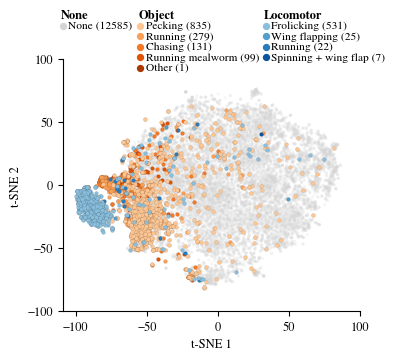

In [16]:
with plt.style.context(".matplotlib/ieee.mplstyle"):
    fig = plt.figure(figsize=(3.5, 3.5))
    leg_ax = fig.add_axes([0.05, 0.82, 0.92, 0.12])
    ax = fig.add_axes([0.10, 0.10, 0.85, 0.72])

    # Background: none
    ax.scatter(
        X_tsne_single[none_mask_single.values, 0], X_tsne_single[none_mask_single.values, 1],
        c=color_map["None"], s=5, alpha=0.2, edgecolors="none",
    )

    # Active behaviours on top
    for group in ["worm", "locomotor"]:
        gmask = single_df["behav_label"] == group
        behavs = single_df.loc[gmask, "behav_primary"].value_counts().index.tolist()
        for behav in reversed(behavs):
            bmask = single_df["behav_primary"] == behav
            c = color_map.get(behav, "#888888")
            ax.scatter(
                X_tsne_single[bmask.values, 0], X_tsne_single[bmask.values, 1],
                c=[c], s=8, alpha=1.0, edgecolors="k", linewidth=0.05
            )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    # Custom legend (3-class, no social)
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")

    short_labels = {
        "Worm pecking": "Pecking",
        "Worm running": "Running",
        "Worm chasing": "Chasing",
        "Worm running mealworm": "Running mealworm",
        "Wing flapping": "Wing flapping",
        "Spinning while wing flapping": "Spinning + wing flap",
    }

    col_entries_single = {}
    for group in ["none", "worm", "locomotor"]:
        entries = []
        if group == "none":
            n = none_mask_single.sum()
            entries.append((color_map["None"], f"None ({n})"))
        else:
            behavs = single_df.loc[single_df["behav_label"] == group, "behav_primary"].value_counts()
            for behav, count in behavs.items():
                label = short_labels.get(behav, behav)
                entries.append((color_map.get(behav, "#888888"), f"{label} ({count})"))
        col_entries_single[group] = entries

    max_rows_s = max(len(e) for e in col_entries_single.values())
    # Vertical spacing between rows
    row_height_s = 0.25
    # Horizontal positions for each column
    col_x_s = [0.05, 0.29, 0.68]

    for col_idx, group in enumerate(["none", "worm", "locomotor"]):
        x = col_x_s[col_idx]
        y = 1.05
        leg_ax.text(x, y, group_labels[group].replace("Worm", "Object"), fontweight="bold", fontsize=9,
                    va="center", transform=leg_ax.transAxes)
        for row_idx, (color, label) in enumerate(col_entries_single[group]):
            y = 1.05 - (row_idx + 1) * row_height_s
            leg_ax.scatter(
                x + 0.005, y, c=[color], s=18,
                transform=leg_ax.transAxes, clip_on=False, zorder=0
            )

            leg_ax.text(
                x + 0.022, y, label.replace("Other worm", "Other"), va="center",
                linespacing=1.0, transform=leg_ax.transAxes, fontsize=8.25
            )
            leg_ax.set_zorder(10)
    ax.set_xticks([-100, -50, 0, 50, 100])
    ax.set_yticks([-100, -50, 0, 50, 100])
    ax.tick_params(labelsize=9)
    ax.set_xlabel("t-SNE 1", fontsize=9)
    ax.set_ylabel("t-SNE 2", fontsize=9)
    sns.despine()
    plt.savefig("img/tsne_vjepa2.1.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [38]:
from sklearn.neighbors import NearestNeighbors

K = 1
nn = NearestNeighbors(n_neighbors=K + 1, metric="cosine").fit(X_single)
_, neighbor_idx = nn.kneighbors(X_single)
neighbor_idx = neighbor_idx[:, 1:]  # drop self

fine   = np.asarray(single_df["behav_primary"], dtype=object)
coarse = np.asarray(single_df["behav_label"],   dtype=object)

single_df["purity_fine"]   = (fine[neighbor_idx]   == fine[:, None]).mean(axis=1)
single_df["purity_coarse"] = (coarse[neighbor_idx] == coarse[:, None]).mean(axis=1)

def purity_table(col, key):
    freq = single_df[key].value_counts(normalize=True)
    t = single_df.groupby(key).agg(n=(col, "size"), purity=(col, "mean"))
    t["chance"] = freq
    t["lift"]   = t["purity"] / t["chance"]
    return t.sort_values("purity", ascending=False)

print(f"kNN purity (k={K}, cosine), V-JEPA 2.1 + features penultimate\n")
print("Coarse (3-class):")
print(purity_table("purity_coarse", "behav_label").round(3).to_string())
print("\nFine-grained:")
print(purity_table("purity_fine", "behav_primary").round(3).to_string())

kNN purity (k=1, cosine), V-JEPA 2.1 + features penultimate

Coarse (3-class):
                 n  purity  chance    lift
behav_label                               
none         12585   0.951   0.867   1.096
locomotor      585   0.699   0.040  17.347
worm          1345   0.480   0.093   5.175

Fine-grained:
                                  n  purity  chance    lift
behav_primary                                              
None                          12585   0.951   0.867   1.096
Frolicking                      531   0.708   0.037  19.356
Worm running                    279   0.455   0.019  23.682
Worm pecking                    835   0.315   0.058   5.475
Worm running mealworm            99   0.263   0.007  38.505
Worm chasing                    131   0.183   0.009  20.300
Wing flapping                    25   0.080   0.002  46.448
Spinning while wing flapping      7   0.000   0.000   0.000
Other worm                        1   0.000   0.000   0.000
Running                        

## Other

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

runs = [
    ("XGBoost (features)", "20260322_112743_xgboost"),
    ("MLP (features)", "20260322_112816_mlp"),
    ("DINOv3 ViT-B", "20260323_172818_temporal_cnn2"),
    ("DINOv3 ViT-L", "20260322_113256_temporal_cnn2"),
    ("DINOv3 ViT-H", "20260323_214731_temporal_cnn2"),
    ("VideoPrism Base", "20260323_212743_temporal_cnn2"),
    ("VideoPrism Large", "20260323_210137_temporal_cnn2"),
    ("V-JEPA 2 ViT-L", "20260323_134910_temporal_cnn2"),
    ("V-JEPA 2.1 ViT-B", "20260323_172125_temporal_cnn2"),
    ("V-JEPA 2.1 ViT-L", "20260322_182231_temporal_cnn2"),
    ("feat + DINOv3 ViT-L", "20260322_113817_temporal_cnn2"),
    ("feat + DINOv3 ViT-H", "20260323_214133_temporal_cnn2"),
    ("feat + V-JEPA 2.1 ViT-L", "20260322_150756_temporal_cnn2"),
    ("feat + CID V-JEPA 2.1", "20260323_121450_temporal_cnn2"),
]

rows = []
for name, run_id in runs:
    npy = Path(f"data/eval/{run_id}/loco_test_confusion_matrix.npy")
    if not npy.exists():
        continue
    cm = np.load(npy)
    precision = np.diag(cm) / cm.sum(axis=0).clip(1)
    recall = np.diag(cm) / cm.sum(axis=1).clip(1)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    rows.append({"Model": name, "Worm F1": f1[1], "Locomotor F1": f1[2], "Macro F1": f1.mean()})

df_f1 = pd.DataFrame(rows).set_index("Model")
df_f1 = df_f1.style.format("{:.3f}").highlight_max(axis=0, props="font-weight: bold")
df_f1

,Worm F1,Locomotor F1,Macro F1
Model,,,
XGBoost (features),0.532,0.765,0.748
MLP (features),0.532,0.730,0.734
DINOv3 ViT-B,0.480,0.703,0.707
DINOv3 ViT-L,0.534,0.745,0.740
DINOv3 ViT-H,0.509,0.751,0.734
VideoPrism Base,0.542,0.732,0.738
VideoPrism Large,0.545,0.741,0.741
V-JEPA 2 ViT-L,0.540,0.744,0.743
V-JEPA 2.1 ViT-B,0.581,0.749,0.758


In [42]:
def linear_cka(X, Y):
    """Linear CKA (unbiased HSIC estimator, Kornblith et al. 2019 / Nguyen et al. 2020)."""
    X = X - X.mean(0)
    Y = Y - Y.mean(0)

    N = X.shape[0]

    K = X @ X.T
    L = Y @ Y.T

    # Zero out diagonals (unbiased estimator)
    K.fill_diagonal_(0)
    L.fill_diagonal_(0)

    hsic_kl = (K * L).sum() / ((N - 1) * (N - 2))
    hsic_kk = (K * K).sum() / ((N - 1) * (N - 2))
    hsic_ll = (L * L).sum() / ((N - 1) * (N - 2))

    return (hsic_kl / (hsic_kk.sqrt() * hsic_ll.sqrt())).item()


# Load embeddings and mean-pool per window
emb_files = {
    "features": "features_windowed.parquet",
    "DINOv3 ViT-L": "embeddings_dinov3_vitl.pt",
    "VP Large": "embeddings_videoprism_vitl_temporal.pt",
    "V-JEPA 2 ViT-L": "embeddings_vjepa2_vitl_temporal.pt",
    "V-JEPA 2.1 ViT-L": "embeddings_vjepa21_vitl_temporal.pt",
}

labels = pd.read_parquet("data/dataset/labels.parquet")
keys = list(labels[["video_id", "bird_id", "window"]].itertuples(index=False, name=None))

representations = {}
for name, fname in emb_files.items():
    path = Path(f"data/dataset/{fname}")
    if fname.endswith(".parquet"):
        df_feat = pd.read_parquet(path)
        # Keep only numeric feature columns
        drop_cols = ["video_id", "bird_id", "window"]
        numeric = df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns])
        numeric = numeric.select_dtypes(include="number")
        # Impute NaN with column median
        numeric = numeric.fillna(numeric.median())
        X = torch.tensor(numeric.values, dtype=torch.float32)
    else:
        emb = torch.load(path, weights_only=False)
        X = torch.stack([emb[k].float().mean(0) for k in keys])  # mean-pool temporal
    representations[name] = X
    print(f"{name}: {X.shape}")

# Compute CKA matrix
names = list(representations.keys())
n = len(names)
cka_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        cka_matrix[i, j] = linear_cka(representations[names[i]], representations[names[j]])

cka_matrix = pd.DataFrame(cka_matrix, index=names, columns=names)

features: torch.Size([14716, 172])
DINOv3 ViT-L: torch.Size([14716, 1024])
VP Large: torch.Size([14716, 1024])
V-JEPA 2 ViT-L: torch.Size([14716, 1024])
V-JEPA 2.1 ViT-L: torch.Size([14716, 1024])


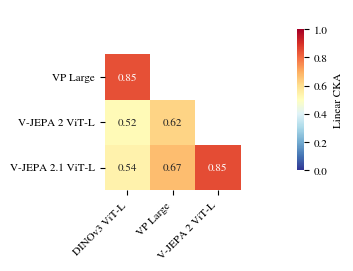

In [19]:
# Plot heatmap
cka_matrix_no_features = cka_matrix.drop(index="features", columns="features")
mask = np.triu(np.ones_like(cka_matrix_no_features, dtype=bool), k=0)
with plt.style.context(".matplotlib/ieee.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    sns.heatmap(
        cka_matrix_no_features,
        annot=True,
        square=True,
        cmap="RdYlBu_r",
        mask=mask,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Linear CKA", "shrink": 0.5},
        ax=ax,
    )
    ax.set_xticks(ax.get_xticks()[:-1])
    ax.set_yticks(ax.get_yticks()[1:])
    ax.set_xticklabels(cka_matrix_no_features.columns[:-1], rotation=45, ha="right")
    ax.set_yticklabels(cka_matrix_no_features.index[1:])

    plt.tight_layout()
    plt.savefig("img/cka_heatmap.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.savefig("img/cka_heatmap.svg", bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [20]:
# Load tracks and compute mean tracker_score per window
tracks = pd.read_parquet("data/dataset/tracks.parquet")
window_scores = (
    tracks.groupby(["video_id", "bird_id", "window"])["tracker_score"]
    .mean()
    .reset_index()
    .rename(columns={"tracker_score": "mean_tracker_score"})
)

labels = pd.read_parquet("data/dataset/labels.parquet")
labels = labels[labels["behav_label"] != "social"]  # match --exclude social

# Merge scores with labels
labels = labels.merge(window_scores, on=["video_id", "bird_id", "window"])

# Bin tracker scores and check error rate per bin
labels["score_bin"] = pd.cut(labels["mean_tracker_score"], bins=10)
# We need predictions to complete this — save from the fold loop above

# For now, a simpler version that doesn't need per-fold predictions — just correlate tracker score with window coverage (proxy for tracking quality):

tracks = pd.read_parquet("data/dataset/tracks.parquet")
labels = pd.read_parquet("data/dataset/labels.parquet")

window_stats = tracks.groupby(["video_id", "bird_id", "window"]).agg(
    mean_score=("tracker_score", "mean"),
    min_score=("tracker_score", "min"),
    n_frames=("frame_idx", "count"),
).reset_index()

# Windows with low mean score — are these the ones that get misclassified?
print(window_stats["mean_score"].describe())
print(f"\nWindows with mean_score < 0.5: {(window_stats['mean_score'] < 0.5).sum()}")
print(f"Windows with mean_score < 0.7: {(window_stats['mean_score'] < 0.7).sum()}")

count    14716.000000
mean         0.994414
std          0.022482
min          0.336219
25%          0.999250
50%          1.000000
75%          1.000000
max          1.000000
Name: mean_score, dtype: float64

Windows with mean_score < 0.5: 3
Windows with mean_score < 0.7: 10


In [21]:
labels = pd.read_parquet("data/dataset/labels.parquet")

fine = (
    labels.groupby(["behav_label", "behav"])
    .size()
    .reset_index(name="count")
    .sort_values(["behav_label", "count"], ascending=[True, False])
)
fine["pct"] = fine.groupby("behav_label")["count"].transform(lambda x: x / x.sum() * 100)

# Format as a styled table
fine_display = fine.copy()
fine_display["pct"] = fine_display["pct"].map("{:.1f}%".format)
fine_display.columns = ["Group", "Behaviour", "Count", "% of group"]
print(fine_display)

        Group                                          Behaviour  Count  \
0   locomotor                                         Frolicking    492   
4   locomotor                           Frolicking, Worm pecking     27   
13  locomotor                                      Wing flapping     25   
7   locomotor                                            Running     14   
12  locomotor                       Spinning while wing flapping      7   
3   locomotor                           Frolicking, Worm chasing      5   
9   locomotor                              Running, Worm pecking      4   
5   locomotor                           Frolicking, Worm running      3   
6   locomotor                  Frolicking, Worm running mealworm      2   
11  locomotor                Running, Worm running, Worm pecking      2   
1   locomotor           Frolicking, Spinning while wing flapping      1   
2   locomotor                          Frolicking, Wing flapping      1   
8   locomotor            

In [14]:
# Extract per-window predictions from each LOCO fold
labels_full = pd.read_parquet("data/dataset/labels.parquet")
labels_excl = labels_full[~labels_full["behav_label"].isin(["social"])].reset_index(drop=True)

all_preds = []
all_true_labels = []
all_indices = []  # indices into labels_excl

for fold_idx, (test_id, val_id) in enumerate(dm.splitter.split(dm.video_ids)):
    dm.set_fold(test_id=test_id, val_id=val_id)
    dm.setup()

    fold_dir = RUN_DIR / f"fold_{fold_idx}_{test_id}"
    ckpt_path = sorted((fold_dir / "checkpoints").glob("*.ckpt"))[0]

    lit_model = BehaviourClassifier(
        backbone=backbone_cls(dm.data_dim, dm.n_classes, **backbone_kwargs),
        n_classes=dm.n_classes, lr=cfg["lr"],
    )
    lit_model.load_state_dict(torch.load(ckpt_path, weights_only=True)["state_dict"], strict=False)
    lit_model.eval()
    backbone = lit_model.backbone

    test_indices = dm.test_ds.indices
    dataset = dm._dataset

    for idx in test_indices:
        sample = dataset[idx]
        data = sample["data"].unsqueeze(0)
        flat = sample["flat"].unsqueeze(0) if "flat" in sample and sample["flat"] is not None else None

        with torch.no_grad():
            logits = backbone(data, flat=flat) if flat is not None else backbone(data)

        all_preds.append(logits.argmax(1).item())
        all_true_labels.append(sample["label"].item())
        all_indices.append(idx)

    print(f"Fold {fold_idx} ({test_id}): {len(test_indices)} samples")

# Build results by joining predictions with the labels dataframe
results = labels_excl.iloc[all_indices].copy().reset_index(drop=True)
results["true_label"] = [dm.label_encoder.decode([l])[0] for l in all_true_labels]
results["pred_label"] = [dm.label_encoder.decode([p])[0] for p in all_preds]
results["correct"] = results["true_label"] == results["pred_label"]
results["behav_primary"] = results["behav"].str.split(",").str[0].str.strip()

# print(f"\nExtracted {len(all_preds)} predictions, accuracy: {results['correct'].mean():.1%}")

2026-05-18 11:47:58.058 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8602  val=2895  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3502, 1.0428, 1.6070])
2026-05-18 11:47:58.059 | INFO     | src.classification.datamodule:setup:393 - Test: 3018 samples


2026-05-18 11:48:46.465 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8735  val=2885  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3500, 1.1386, 1.5114])
2026-05-18 11:48:46.466 | INFO     | src.classification.datamodule:setup:393 - Test: 2895 samples


Fold 0 (C1): 3018 samples


2026-05-18 11:49:27.612 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8739  val=2891  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3592, 1.0182, 1.6226])
2026-05-18 11:49:27.613 | INFO     | src.classification.datamodule:setup:393 - Test: 2885 samples


Fold 1 (C2): 2895 samples


2026-05-18 11:50:06.672 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8798  val=2826  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3276, 1.0519, 1.6205])
2026-05-18 11:50:06.674 | INFO     | src.classification.datamodule:setup:393 - Test: 2891 samples


Fold 2 (C3): 2885 samples


2026-05-18 11:50:47.467 | INFO     | src.classification.datamodule:setup:386 - Fit: train=8671  val=3018  classes=['none', 'worm', 'locomotor']  weights=tensor([0.3344, 1.0256, 1.6401])
2026-05-18 11:50:47.471 | INFO     | src.classification.datamodule:setup:393 - Test: 2826 samples


Fold 3 (C4): 2891 samples
Fold 4 (C5): 2826 samples


In [26]:
# Per sub-behaviour recall ranked within each group, with main confusion target
rows = []
for group in ["worm", "locomotor"]:
    grp = results[results["behav_label"] == group]

    sub_stats = grp.groupby("behav_primary").agg(
        n=("correct", "size"),
        recall=("correct", "mean"),
    ).query("n >= 5").sort_values("recall", ascending=False)

    for behav in sub_stats.index:
        mask = grp["behav_primary"] == behav
        errors = grp[mask & ~grp["correct"]]
        if len(errors) > 0:
            top_class = errors["pred_label"].value_counts().index[0]
            top_pct = errors["pred_label"].value_counts().iloc[0] / mask.sum()
            top_confusion = f"{top_class} ({top_pct:.1%})"
        else:
            top_confusion = "-"
        rows.append({
            "Group": group,
            "Sub-behaviour": behav,
            "N": sub_stats.loc[behav, "n"],
            "Recall": sub_stats.loc[behav, "recall"],
            "Main confusion": top_confusion,
        })

display_df = pd.DataFrame(rows)
display_df["Recall"] = display_df["Recall"].map("{:.1%}".format)

print(display_df.set_index("Sub-behaviour"))

                                  Group    N Recall Main confusion
Sub-behaviour                                                     
Worm running                       worm  279  90.0%    none (8.6%)
Worm running mealworm              worm   99  68.7%   none (28.3%)
Worm pecking                       worm  835  58.9%   none (39.5%)
Worm chasing                       worm  131  58.8%   none (29.0%)
Wing flapping                 locomotor   25  92.0%    none (8.0%)
Frolicking                    locomotor  531  87.9%    none (7.5%)
Spinning while wing flapping  locomotor    7  85.7%   none (14.3%)
Running                       locomotor   15   0.0%   worm (66.7%)


In [27]:
# Is misclassification correlated with bird proximity (clumping)?
features_w = pd.read_parquet("data/dataset/features_windowed.parquet")

results_feat = results.merge(
    features_w[["video_id", "bird_id", "window", "min_dist_to_other_mean"]],
    on=["video_id", "bird_id", "window"], how="left",
)

# Bin min_dist into quartiles
results_feat["dist_quartile"] = pd.qcut(
    results_feat["min_dist_to_other_mean"], q=4,
    labels=["Q1 (closest)", "Q2", "Q3", "Q4 (farthest)"]
)

# Compute recall per quartile per group, pivot into a nice table
recall_by_dist = (
    results_feat.groupby(["behav_label", "dist_quartile"])["correct"]
    .mean()
    .unstack(level="behav_label")
)
recall_by_dist = recall_by_dist[["none", "worm", "locomotor"]]
recall_by_dist.columns = ["None", "Worm", "Locomotor"]
recall_by_dist.index.name = "Proximity to nearest neighbor"

print(recall_by_dist.to_string(float_format="{:.1%}".format))

                               None  Worm  Locomotor
Proximity to nearest neighbor                       
Q1 (closest)                  99.2% 40.8%      60.0%
Q2                            96.8% 51.8%      74.1%
Q3                            90.8% 70.0%      81.3%
Q4 (farthest)                 84.2% 72.0%      86.6%


In [28]:
# Per-class F1 when excluding high-clumping windows
from sklearn.metrics import f1_score, classification_report

le = dm.label_encoder

for label, exclude_qs in [("Full dataset", []), ("Excl. Q1", ["Q1 (closest)"]), ("Excl. Q1+Q2", ["Q1 (closest)", "Q2"])]:
    if exclude_qs:
        mask = ~results_feat["dist_quartile"].isin(exclude_qs)
    else:
        mask = pd.Series(True, index=results_feat.index)
    subset = results_feat[mask]

    y_true = le.encode(subset["true_label"].tolist())
    y_pred = le.encode(subset["pred_label"].tolist())

    per_class = f1_score(y_true, y_pred, average=None)
    macro = f1_score(y_true, y_pred, average="macro")

    print(f"\n{label} (n={len(subset)})")
    print(f"  None: {per_class[0]:.3f}  Worm: {per_class[1]:.3f}  Loco: {per_class[2]:.3f}  Macro: {macro:.3f}")


Full dataset (n=14515)
  None: 0.948  Worm: 0.619  Loco: 0.744  Macro: 0.770

Excl. Q1 (n=10933)
  None: 0.933  Worm: 0.627  Loco: 0.744  Macro: 0.768

Excl. Q1+Q2 (n=7352)
  None: 0.911  Worm: 0.643  Loco: 0.752  Macro: 0.769


In [29]:
q1 = results_feat[results_feat["dist_quartile"] == "Q1 (closest)"]
print(q1["behav_label"].value_counts())
print(q1["behav_label"].value_counts(normalize=True).map("{:.1%}".format))

behav_label
none         3479
worm           98
locomotor       5
Name: count, dtype: int64
behav_label
none         97.1%
worm          2.7%
locomotor     0.1%
Name: proportion, dtype: str


In [27]:
# Pooled F1 per day
from sklearn.metrics import f1_score

le = dm.label_encoder
results["day"] = results["video_id"].str.extract(r"D(\d+)")[0]

for day in sorted(results["day"].unique()):
    subset = results[results["day"] == day]
    y_true = le.encode(subset["true_label"].tolist())
    y_pred = le.encode(subset["pred_label"].tolist())
    per_class = f1_score(y_true, y_pred, average=None)
    macro = f1_score(y_true, y_pred, average="macro")
    print(f"Day {day} (n={len(subset)}): None={per_class[0]:.3f}  Worm={per_class[1]:.3f}  Loco={per_class[2]:.3f}  Macro={macro:.3f}")

Day 28 (n=7467): None=0.942  Worm=0.597  Loco=0.718  Macro=0.752
Day 29 (n=7048): None=0.954  Worm=0.644  Loco=0.773  Macro=0.790


In [28]:
# Label distribution per day
print("\nLabel distribution per day:")
day_dist = results.groupby(["day", "behav_label"]).size().unstack(fill_value=0)
day_pct = day_dist.div(day_dist.sum(axis=1), axis=0)
day_pct.columns = [c.capitalize() for c in day_pct.columns]
print(day_pct.to_string(float_format="{:.1%}".format))


Label distribution per day:
     Locomotor  None  Worm
day                       
28        4.2% 86.4%  9.4%
29        3.9% 87.0%  9.1%


In [ ]:
from scipy.stats import spearmanr, pointbiserialr

print("Correlation: min_dist_to_other_mean vs correct, per class\n")
for cls in ["none", "worm", "locomotor"]:
    sub = results_feat[results_feat["behav_label"] == cls].dropna(subset=["min_dist_to_other_mean"])
    rho_s, p_s = spearmanr(sub["min_dist_to_other_mean"], sub["correct"].astype(int))
    rho_pb, p_pb = pointbiserialr(sub["correct"].astype(int), sub["min_dist_to_other_mean"])
    print(f"{cls:10s} n={len(sub):5d}  Spearman ρ={rho_s:+.3f} (p={p_s:.2e})  "
          f"point-biserial r={rho_pb:+.3f} (p={p_pb:.2e})")

Correlation: min_dist_to_other_mean vs correct, per class

none       n=12404  Spearman ρ=-0.227 (p=3.13e-144)  point-biserial r=-0.199 (p=1.94e-111)
worm       n= 1342  Spearman ρ=+0.172 (p=2.52e-10)  point-biserial r=+0.144 (p=1.11e-07)
locomotor  n=  579  Spearman ρ=+0.092 (p=2.60e-02)  point-biserial r=+0.084 (p=4.36e-02)
